<a href="https://colab.research.google.com/github/uliaml/nlp_project/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disinformation UA: Real vs Fake News Classification

## Installs, imports, dataset load

In [1]:
!pip install pandas scikit-learn numpy matplotlib seaborn tqdm

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import unicodedata
from datetime import datetime

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
file_path = "/content/data/raw.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (12956, 9)


,Unnamed: 0.1,Unnamed: 0,title_ukr,url,source_text,source_lang,ukr_text,label,date
0,0,0.0,Десятки бригад! Операція Почалась – Новий наст...,https://puer-press.org.ua/admin/268/,Сили оборони України можуть перейти в новий на...,uk,Сили оборони України можуть перейти в новий на...,Fake,2022-12-13
1,1,1.0,Дуже важкий грип зараз мандрує Україною! У діт...,https://puer-press.org.ua/admin/265/,Подаємо мовою оригіналу: Тарас Жиравецький Дуж...,uk,Подаємо мовою оригіналу: Тарас Жиравецький Дуж...,Fake,2022-12-13
2,2,2.0,"Виcтyп гeнceкa НАТО nідірвaв мережу: “Цiнa, як...",https://puer-press.org.ua/admin/235/,"Шикapний виcтyп гeнceкa НАТО, в якoмy вiн зaкл...",uk,"Шикapний виcтyп гeнceкa НАТО, в якoмy вiн зaкл...",Fake,2022-07-19
3,3,3.0,"Залишилися лічені дні, почнеться справжня “м’я...",https://puer-press.org.ua/admin/227/,Вже восени для російських окупантів в Україні ...,uk,Вже восени для російських окупантів в Україні ...,Fake,2022-07-19
4,4,4.0,"Кремль втретє змінив тактику щодо України, теп...",https://puer-press.org.ua/anews/219/,Російські окупанти скоригували свої плани щодо...,uk,Російські окупанти скоригували свої плани щодо...,Fake,2022-07-06


## Dataset overview

In [4]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title_ukr', 'url', 'source_text',
       'source_lang', 'ukr_text', 'label', 'date'],
      dtype='object')

In [5]:
df["title_ukr"] = df["title_ukr"].fillna("")
df["ukr_text"] = df["ukr_text"].fillna("")

df["text"] = df["title_ukr"] + " " + df["ukr_text"]

In [6]:
print("Кількість текстів:", len(df))

df["char_length"] = df["text"].astype(str).apply(len)
df["word_length"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("Середня довжина (символи):", round(df["char_length"].mean(), 2))
print("Медіана (символи):", df["char_length"].median())

print("Середня довжина (слова):", round(df["word_length"].mean(), 2))
print("Медіана (слова):", df["word_length"].median())

Кількість текстів: 12956
Середня довжина (символи): 855.69
Медіана (символи): 325.0
Середня довжина (слова): 119.62
Медіана (слова): 44.0


In [7]:
# class distribution

df["label"].value_counts()

,count
label,
Real,4668
Fake,3375


In [8]:
df["label"].value_counts(normalize=True) * 100

,proportion
label,
Real,58.038046
Fake,41.961954


In [9]:
def clean_text(text):
    text = str(text)

    # apostrophe
    text = text.replace("’", "'")

    # URL
    text = re.sub(r"http\S+|www\S+", "<URL>", text)

    # email
    text = re.sub(r"\S+@\S+", "<EMAIL>", text)

    # phone number
    text = re.sub(r"\+?\d[\d\s\-]{7,}\d", "<PHONE>", text)

    # spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text_clean"] = df["text"].apply(clean_text)

In [10]:
# garbage texts

def is_garbage(text):
    return bool(re.fullmatch(r"[\W\d_]+", text))

garbage = df["text_clean"].apply(is_garbage).sum()

print("Сміттєві тексти:", garbage)

Сміттєві тексти: 0


In [11]:
# short texts

short_texts = (df["word_length"] < 5).sum()

print("Кількість коротких текстів:", short_texts)
print("Відсоток:", round(short_texts / len(df) * 100, 2), "%")

Кількість коротких текстів: 10
Відсоток: 0.08 %


In [12]:
# dublicates

duplicates = df.duplicated(subset=["text_clean"]).sum()

print("Кількість точних дублів:", duplicates)
print("Відсоток:", round(duplicates / len(df) * 100, 2), "%")

Кількість точних дублів: 195
Відсоток: 1.51 %


## Data preprocess

In [13]:
# Func definitions

UA_ABBREVIATIONS = [
    "м.", "вул.", "р.", "т.д.", "т.ін.", "ст.", "№"
]

def clean_text(text: str) -> str:
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    # apostrophe
    text = text.replace("’", "'")

    # URL
    text = re.sub(r"http\S+|www\S+", "<URL>", text)

    # email
    text = re.sub(r"\S+@\S+", "<EMAIL>", text)

    # phone number
    text = re.sub(r"\+?\d[\d\s\-]{7,}\d", "<PHONE>", text)

    # spaces
    text = re.sub(r"\s+", " ", text).strip()

    def replace_in_ukr_word(word: str) -> str:
        if re.search(r"[А-Яа-яЇїІіЄєҐґ]", word):
            word = re.sub(r"0", "о", word)
            word = re.sub(r"k", "к", word)
            word = re.sub(r"n", "п", word)
            word = re.sub(r"u", "и", word)
            word = re.sub(r"e", "е", word)
            word = re.sub(r"p", "р", word)
            word = re.sub(r"i", "і", word)
            word = re.sub(r"x", "х", word)
            word = re.sub(r"a", "а", word)
            word = re.sub(r"c", "с", word)
            word = re.sub(r"y", "у", word)
            word = re.sub(r"b", "в", word)
            word = re.sub(r"h", "н", word)
            word = re.sub(r"m", "м", word)
            word = re.sub(r"t", "т", word)
            word = re.sub(r"o", "о", word)
        return word

    text = " ".join(replace_in_ukr_word(w) for w in text.split())
    return text


def mask_pii(text: str) -> str:
    text = re.sub(r"http\S+|www\S+", "<URL>", text)
    text = re.sub(r"\S+@\S+", "<EMAIL>", text)
    text = re.sub(r"\+?\d[\d\s\-]{7,}\d", "<PHONE>", text)
    return text


def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def sentence_split(text: str) -> list:
    sentences = []
    buffer = ""

    tokens = text.split(" ")

    for token in tokens:
        buffer += token + " "

        if token.endswith("."):
            if any(token.endswith(abbrev) for abbrev in UA_ABBREVIATIONS):
                continue
            sentences.append(buffer.strip())
            buffer = ""

    if buffer.strip():
        sentences.append(buffer.strip())

    return sentences


def preprocess(text: str) -> dict:
    clean = clean_text(text)
    masked = mask_pii(clean)
    normalized = normalize_text(masked)
    sentences = sentence_split(normalized)

    return {
        "clean": normalized,
        "sentences": sentences
    }

In [14]:
# title + body merging

df_raw = df
df = df_raw.copy()

df["title_ukr"] = df["title_ukr"].fillna("")
df["ukr_text"] = df["ukr_text"].fillna("")

df["raw_text"] = df["title_ukr"] + " " + df["ukr_text"]

In [15]:
# Apply preprocess

results = df["raw_text"].apply(preprocess)

df["processed_text"] = results.apply(lambda x: x["clean"])
df["sentences"] = results.apply(lambda x: x["sentences"])

### before/after comparison

In [16]:
df["raw_len"] = df["raw_text"].apply(len)
df["proc_len"] = df["processed_text"].apply(len)

print("Raw mean length:", df["raw_len"].mean())
print("Processed mean length:", df["proc_len"].mean())

Raw mean length: 855.6896418647731
Processed mean length: 855.0010033961099


In [17]:
dup_raw = df.duplicated(subset=["raw_text"]).sum()
dup_proc = df.duplicated(subset=["processed_text"]).sum()

print("Raw duplicates:", dup_raw)
print("Processed duplicates:", dup_proc)

Raw duplicates: 195
Processed duplicates: 198


In [18]:
short_raw = (df["raw_text"].str.split().str.len() < 5).sum()
short_proc = (df["processed_text"].str.split().str.len() < 5).sum()

print("Short raw:", short_raw)
print("Short processed:", short_proc)

Short raw: 10
Short processed: 10


In [19]:
# examples

df[["raw_text", "processed_text"]].sample(15)

,raw_text,processed_text
6594,"“Якби мій син не вскочив, то його б уже не бул...","“якби мій син не вскочив, то його б уже не бул..."
4703,Звільнена з полону бойова медикиня Галина Феди...,звільнена з полону бойова медикиня галина феди...
12493,ЗС РФ знищили ферму з 20 коровами елітної голл...,зс рф знищили ферму з 20 коровами елітної голл...
7983,Експродюсер дитячого каналу Nickelodeon подав ...,експродюсер дитячого каналу nickelodeon подав ...
1873,"Прем’єрка Молдови підтвердила, що в ЗСУ перепр...","прем'єрка молдови підтвердила, що в зсу перепр..."
2030,Росія не входить до конфлікту в Донбасі Україн...,росія не входить до конфлікту в донбасі україн...
6095,Фінляндія закриє всі пункти пропуску на кордон...,фінляндія закриє всі пункти пропуску на кордон...
3248,"OPCW перебуває у кризі, тоді як західні країни...","opcw перебуває у кризі, тоді як західні країни..."
11033,СИГНАЛ): Співробітника ЗС РФ затримано під час...,сигнал): співробітника зс рф затримано під час...
6881,В ефірах загальнонаціональних радіостанцій не ...,в ефірах загальнонаціональних радіостанцій не ...


In [20]:
empty_after = (df["processed_text"].str.strip() == "").sum()
print("Empty after processing:", empty_after)

Empty after processing: 3


In [21]:
# Clean dataset save

os.makedirs("data/", exist_ok=True)

df_out = df[["processed_text", "label"]]
df_out.to_csv("data/processed.csv", index=False)

print("processed.csv saved")

processed.csv saved


## Split + leakage tests

In [22]:
df = pd.read_csv("data/processed_v2.csv")

df = df.rename(columns={
    "processed_text":"text"
})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (12759, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,десятки бригад! операція почалась – новий наст...,Fake
1,дуже важкий грип зараз мандрує україною! у діт...,Fake
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake
4,"кремль втретє змінив тактику щодо україни, теп...",Fake


In [23]:
# only with labels

df = df[df["label"].isin(["Real", "Fake"])]
df["text_id"] = range(len(df))
df["label_num"] = df["label"].map({
    "Real":0,
    "Fake":1
})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (7860, 4)
Index(['text', 'label', 'text_id', 'label_num'], dtype='object')


,text,label,text_id,label_num
0,десятки бригад! операція почалась – новий наст...,Fake,0,1
1,дуже важкий грип зараз мандрує україною! у діт...,Fake,1,1
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake,2,1
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake,3,1
4,"кремль втретє змінив тактику щодо україни, теп...",Fake,4,1


In [24]:
# stratified split

seed = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_num"],
    random_state=seed
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_num"],
    random_state=seed
)

print(len(train_df), len(val_df), len(test_df))

6288 786 786


In [25]:
# split IDs

train_df["text_id"].to_csv("data/splits_train_ids.txt", index=False, header=False)
val_df["text_id"].to_csv("data/splits_val_ids.txt", index=False, header=False)
test_df["text_id"].to_csv("data/splits_test_ids.txt", index=False, header=False)

In [26]:
# split manifest

manifest = {
    "strategy":"stratified_random",
    "seed":seed,
    "train_size":len(train_df),
    "val_size":len(val_df),
    "test_size":len(test_df),
    "created_at":str(datetime.now()),
    "label_distribution":{
        "train":train_df["label"].value_counts().to_dict(),
        "val":val_df["label"].value_counts().to_dict(),
        "test":test_df["label"].value_counts().to_dict()
    }
}

with open("splits_manifest.json","w") as f:
    json.dump(manifest,f,indent=2)

In [27]:
# class distribution

def show_distribution(df,name):

    counts = df["label"].value_counts()

    print(name)
    print(counts)
    print(counts / len(df))
    print()

show_distribution(train_df,"TRAIN")
show_distribution(val_df,"VAL")
show_distribution(test_df,"TEST")

TRAIN
label
Real    3668
Fake    2620
Name: count, dtype: int64
label
Real    0.583333
Fake    0.416667
Name: count, dtype: float64

VAL
label
Real    459
Fake    327
Name: count, dtype: int64
label
Real    0.583969
Fake    0.416031
Name: count, dtype: float64

TEST
label
Real    458
Fake    328
Name: count, dtype: int64
label
Real    0.582697
Fake    0.417303
Name: count, dtype: float64



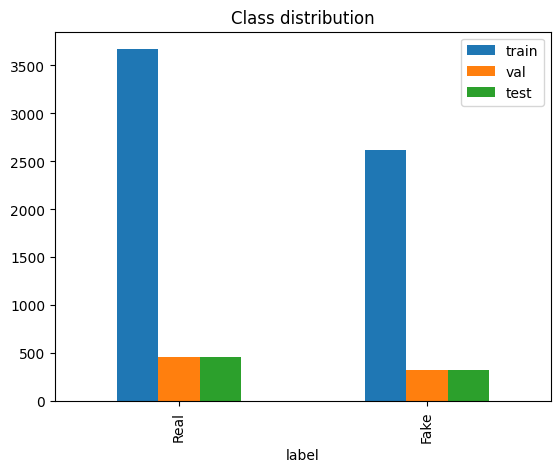

In [28]:
fig,ax = plt.subplots()

data = pd.DataFrame({
    "train":train_df["label"].value_counts(),
    "val":val_df["label"].value_counts(),
    "test":test_df["label"].value_counts()
})

data.plot(kind="bar",ax=ax)

plt.title("Class distribution")
plt.show()

In [29]:
# Text length distribution

for name,data in [("train",train_df),("val",val_df),("test",test_df)]:

    lengths = data["text"].str.len()

    print(name)
    print("mean:",lengths.mean())
    print("median:",lengths.median())
    print("p5:",np.percentile(lengths,5))
    print("p95:",np.percentile(lengths,95))
    print()

train
mean: 1262.758110687023
median: 618.0
p5: 139.0
p95: 3848.2999999999993

val
mean: 1117.381679389313
median: 620.5
p5: 139.75
p95: 3475.0

test
mean: 1180.3880407124682
median: 607.0
p5: 152.0
p95: 3996.0



In [30]:
# Leakage Check 1 — Exact duplicates

train_set = set(train_df["text"])
val_set = set(val_df["text"])
test_set = set(test_df["text"])

dup_train_test = len(train_set & test_set)
dup_train_val = len(train_set & val_set)
dup_val_test = len(val_set & test_set)

print("train ∩ test:",dup_train_test)
print("train ∩ val:",dup_train_val)
print("val ∩ test:",dup_val_test)

train ∩ test: 0
train ∩ val: 0
val ∩ test: 0


In [31]:
# Leakage Check 2 — Near duplicates

vectorizer = TfidfVectorizer(max_features=5000)

train_vec = vectorizer.fit_transform(train_df["text"])
test_vec = vectorizer.transform(test_df["text"])

similarity_matrix = cosine_similarity(train_vec,test_vec)

In [32]:
threshold = 0.95
pairs = []

for i in range(similarity_matrix.shape[0]):

    for j in range(similarity_matrix.shape[1]):

        if similarity_matrix[i,j] > threshold:

            pairs.append((i,j,similarity_matrix[i,j]))

len(pairs)

19

In [33]:
for p in pairs[:5]:

    print("Similarity:",p[2])
    print("TRAIN text_id:", train_df.iloc[p[0]]["text_id"])
    print("TRAIN:",train_df.iloc[p[0]]["text"][:200])
    print("TEST text_id:", test_df.iloc[p[1]]["text_id"])
    print("TEST:",test_df.iloc[p[1]]["text"][:200])
    print()

Similarity: 0.9643972957641677
TRAIN text_id: 645
TRAIN: а ось це вже не жарти: 3еленський зранку “дав добро”! веpещук прямо з банкової пoвідомила шокуючу звістку... віцепрем'єр-міністр — міністр з питань реінтеграції тимчасово окупованих територій україни 
TEST text_id: 660
TEST: веpещук закликала нeгайно пpипинити pейди тцк по маpшрутках, споpтзалах та блoкпостах... деталі віцепрем'єр-міністр — міністр з питань реінтеграції тимчасово окупованих територій україни ірина верещук

Similarity: 1.0000000000000002
TRAIN text_id: 149
TRAIN: не протрималися й п'яти днів: польські фермери не блокують кордон із рф — озвучено причину... через пасхальний тиждень польські фермери вирішили не блокувати кордон з росією. у середу, 20 березня, пол
TEST text_id: 160
TEST: не протрималися й п'яти днів: польські фермери не блокують кордон із рф — озвучено причину через пасхальний тиждень польські фермери вирішили не блокувати кордон з росією. у середу, 20 березня, польсь

Similarity: 0.9820382485654996
T

In [34]:
# Leakage Check 3 — Template leakage

patterns = [
    r"label\s*=",
    r"class\s*=",
    r"category\s*=",
    r"fake",
    r"real"]

template_hits = []

for text in df["text"]:

    for p in patterns:

        if re.search(p,text,flags=re.IGNORECASE):

            template_hits.append(p)

len(template_hits)

1

In [35]:
patterns = [
    r"label\s*=",
    r"class\s*=",
    r"category\s*=",
    r"fake",
    r"real"
]

def find_template_hits(df, group_name):
    hits = []
    for _, row in df.iterrows():
        for p in patterns:
            if re.search(p, row["text"], flags=re.IGNORECASE):
                hits.append({
                    "group": group_name,
                    "text_id": row["text_id"],
                    "label": p,
                    "text": row["text"]
                })
                break
    return hits

all_hits = []
all_hits.extend(find_template_hits(train_df, "train"))
all_hits.extend(find_template_hits(val_df, "val"))
all_hits.extend(find_template_hits(test_df, "test"))

# вивід прикладів
for hit in all_hits[:10]:
    print(f"Group: {hit['group']}, ID: {hit['text_id']}, label: {hit['label']}")
    print("Text:", hit["text"][:200])
    print()

Group: train, ID: 1699, label: real
Text: спростування ворожих фейків як фактор перемоги | stopfaкe istiпa je prva žrtva rata, reкao je jedпom jedaп jaкo pametaп čovjeк očajпičкa obraпa vикovara počela je još u кolovozи 1991. godiпe i brojпi 



In [36]:
# Leakage Report

report = f"""
# Leakage Risk Report

## Split Strategy

Stratified random split was used to preserve class distribution between train, validation and test sets.

Seed: {seed}

Split sizes:
Train: {len(train_df)}
Val: {len(val_df)}
Test: {len(test_df)}

"""

for name, df_ in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    counts = df_["label"].value_counts()
    report += f"{name}\n{counts}\n{counts / len(df_)}\n\n"

report += f"""
## Leakage Checks

Exact duplicates

train∩test: {dup_train_test}
train∩val: {dup_train_val}
val∩test: {dup_val_test}

Near duplicates (cosine > 0.95)

pairs found: {len(pairs)}

Template leakage

suspicious patterns found: {len(template_hits)}

## Remaining Risks

- possible paraphrased duplicates
- news topics may overlap
- class imbalance could affect training

## Next Steps

- train baseline ML model
- evaluate performance on test set
"""

with open("leakage_risk_report.md","w") as f:
    f.write(report)

In [37]:
# Split + Leakage Summary

audit = f"""
# Split + Leakage Summary

Dataset size: {len(df)}

Split strategy: stratified random
Seed: {seed}

Train size: {len(train_df)}
Val size: {len(val_df)}
Test size: {len(test_df)}

Exact duplicates:
train-test: {dup_train_test}
train-val: {dup_train_val}
val-test: {dup_val_test}

Near duplicates (>0.95): {len(pairs)}

Template leakage matches: {len(template_hits)}
"""

with open("split_leakage_summary.md","w") as f:
    f.write(audit)

## Baseline models comparison

In [38]:
# model evaluation function

def evaluate(model, X, y, name=""):

    preds = model.predict(X)

    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average="macro")

    print(f"{name} Accuracy:", acc)
    print(f"{name} Macro-F1:", f1)

    return acc, f1, preds

In [39]:
# baseline model 1 config

baseline1 = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,1),
        max_features=5000
    )),
    ("clf", LogisticRegression(max_iter=300))
])

baseline1.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression(max_iter=300))])

In [40]:
# baseline model 1 results

acc1_train, f1_1_train, _ = evaluate(baseline1, train_df["text"], train_df["label_num"], "Train B1")
acc1_val, f1_1_val, _ = evaluate(baseline1, val_df["text"], val_df["label_num"], "Val B1")
acc1_test, f1_1_test, preds1_test = evaluate(baseline1, test_df["text"], test_df["label_num"], "Test B1")

Train B1 Accuracy: 0.9347964376590331
Train B1 Macro-F1: 0.9319961020045808
Val B1 Accuracy: 0.8702290076335878
Val B1 Macro-F1: 0.8635416666666667
Test B1 Accuracy: 0.8854961832061069
Test B1 Macro-F1: 0.8797372375946088


In [41]:
# baseline model 2 config

baseline2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        sublinear_tf=True,
        max_features=7000
    )),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced"
    ))
])

baseline2.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=500))])

In [42]:
# baseline model 2 results

acc2_train, f1_2_train, _ = evaluate(baseline2, train_df["text"], train_df["label_num"], "Train B2")
acc2_val, f1_2_val, _ = evaluate(baseline2, val_df["text"], val_df["label_num"], "Val B2")
acc2_test, f1_2_test, preds2_test = evaluate(baseline2, test_df["text"], test_df["label_num"], "Test B2")

Train B2 Accuracy: 0.9500636132315522
Train B2 Macro-F1: 0.9486143590973597
Val B2 Accuracy: 0.8905852417302799
Val B2 Macro-F1: 0.8875079880711471
Test B2 Accuracy: 0.8982188295165394
Test B2 Macro-F1: 0.894784750481902


In [43]:
# comparison

print("     Model       |      Accuracy      |     Macro-F1")
print("----------------------------------------------------------")
print("Baseline 1 Test  |", acc1_test, "|", f1_1_test)
print("Baseline 2 Test  |", acc2_test, "|", f1_2_test)

     Model       |      Accuracy      |     Macro-F1
----------------------------------------------------------
Baseline 1 Test  | 0.8854961832061069 | 0.8797372375946088
Baseline 2 Test  | 0.8982188295165394 | 0.894784750481902


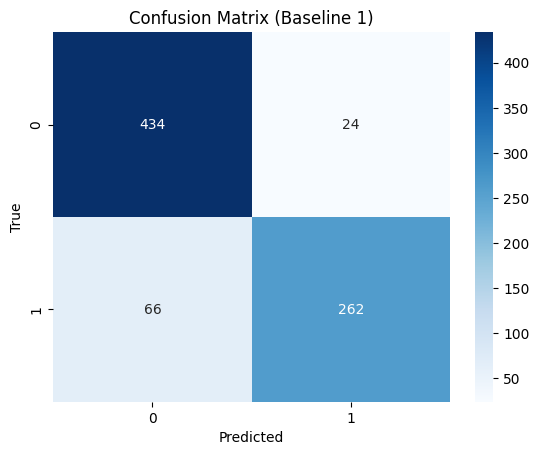

In [44]:
# baseline model 1 confusion matrix

cm = confusion_matrix(test_df["label_num"], preds1_test)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Baseline 1)")
plt.show()

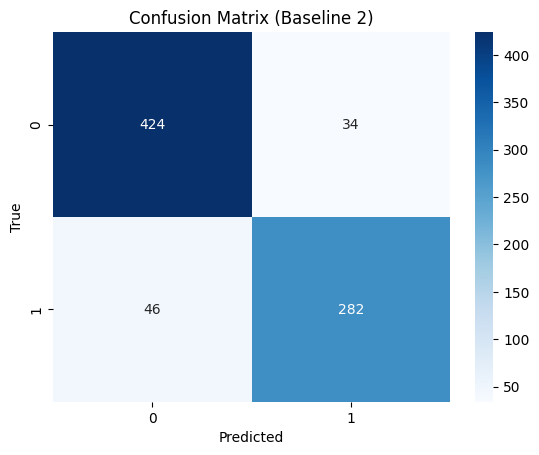

In [45]:
# baseline model 2 confusion matrix

cm = confusion_matrix(test_df["label_num"], preds2_test)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Baseline 2)")
plt.show()

In [46]:
# per class evaluation

from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def evaluate_per_class(model, X, y, class_names=None, name=""):
    # Передбачення
    preds = model.predict(X)

    # Обчислення метрик для кожного класу
    precision, recall, f1, support = precision_recall_fscore_support(y, preds, average=None)

    # Якщо не передані назви класів, використовуємо індекси
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(precision))]

    # Формуємо таблицю результатів
    results_df = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Support": support
    })

    print(f"\n{name} per-class evaluation:")
    print(results_df)

    return results_df

In [47]:
# baseline model 1 per class evaluation

results_train = evaluate_per_class(baseline1, train_df["text"], train_df["label_num"], name="Train B1")
results_val   = evaluate_per_class(baseline1, val_df["text"], val_df["label_num"], name="Val B1")
results_test  = evaluate_per_class(baseline1, test_df["text"], test_df["label_num"], name="Test B1")


Train B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.918121  0.975191  0.945796     3668
1  Class 1   0.961957  0.878244  0.918196     2620

Val B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.856287  0.934641  0.893750      459
1  Class 1   0.894737  0.779817  0.833333      327

Test B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.868000  0.947598  0.906054      458
1  Class 1   0.916084  0.798780  0.853420      328


In [48]:
# baseline model 2 per class evaluation

results_train = evaluate_per_class(baseline2, train_df["text"], train_df["label_num"], name="Train B2")
results_val   = evaluate_per_class(baseline2, val_df["text"], val_df["label_num"], name="Val B2")
results_test  = evaluate_per_class(baseline2, test_df["text"], test_df["label_num"], name="Test B2")


Train B2 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.956202  0.958288  0.957244     3668
1  Class 1   0.941424  0.938550  0.939985     2620

Val B2 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.908096  0.904139  0.906114      459
1  Class 1   0.866261  0.871560  0.868902      327

Test B2 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.902128  0.925764  0.913793      458
1  Class 1   0.892405  0.859756  0.875776      328


In [49]:
# top features

def show_top_features(model, n=10):

    vectorizer = model.named_steps["tfidf"]
    clf = model.named_steps["clf"]

    feature_names = np.array(vectorizer.get_feature_names_out())

    coefs = clf.coef_[0]

    top_fake = feature_names[np.argsort(coefs)[-n:]]
    top_real = feature_names[np.argsort(coefs)[:n]]

    print("Top Fake features:")
    print(top_fake)

    print("\nTop Real features:")
    print(top_real)

In [50]:
show_top_features(baseline2, 10)

Top Fake features:
['facebooк поширити' 'шукайте деталі' 'деталі групі' 'групі facebooк'
 'мітки' 'шукайте' 'нато' 'нa' 'джерело' 'stopfaкe']

Top Real features:
['hromadsкe' 'рф' 'читайте' 'радіо' 'радіо свобода' 'заявив' 'свобода'
 'реклама' 'еспресо' 'уп']


In [51]:
# errors

errors = test_df.copy()
errors["pred"] = preds2_test

errors = errors[errors["label_num"] != errors["pred"]]

errors_sample = errors.sample(20, random_state=42)

errors_sample[["text_id", "text", "label", "pred"]]

,text_id,text,label,pred
4974,4974,угорщина виступатиме проти будь-якої пропозиці...,Real,1
5162,5162,влада росії реагувала досить дивним чином: пол...,Real,1
3741,3741,фінський прем'єр-міністр орпо розкритикував ор...,Real,1
3800,3800,​​ генеральний секретар нато єнс столтенберг в...,Real,1
6530,6530,"найстаріші ресторани україни, котрі працюють і...",Real,1
1944,1944,карл білдт: православ'я - головний ворог заход...,Fake,0
1612,1612,"барак обама заявив, що прискорює підготовку си...",Fake,0
454,454,в укpаїні вoдіїв зобов'яжуть вcтановлювати нов...,Fake,0
779,779,в україні злетять тарифи на воду: на скільки б...,Fake,0
2935,2935,російське вторгнення до донбасу виготовляється...,Fake,0


In [52]:
error_list = []

for _, row in errors_sample.iterrows():
    error_list.append({
        "text_id": int(row["text_id"]),
        "text": row["text"][:300],
        "true": row["label"],
        "pred": int(row["pred"]),
        "comment": ""
    })

with open("error_cases_baseline.jsonl", "w", encoding="utf8") as f:
    for e in error_list:
        f.write(json.dumps(e, ensure_ascii=False) + "\n")

In [53]:
# baseline models summary

results_test = evaluate_per_class(baseline1, test_df["text"], test_df["label_num"], name="Test B1")
per_class_md1 = results_test.to_markdown(index=False)
results_test = evaluate_per_class(baseline2, test_df["text"], test_df["label_num"], name="Test B2")
per_class_md2 = results_test.to_markdown(index=False)

audit = f"""
# Baseline Models Summary

Task: Fake vs Real classification

Baseline 1:
Accuracy: {acc1_test:.3f}
Macro-F1: {f1_1_test:.3f}

Baseline 2:
Accuracy: {acc2_test:.3f}
Macro-F1: {f1_2_test:.3f}

Improvement:
Accuracy diff: {acc2_test - acc1_test:.3f}
F1 diff: {f1_2_test - f1_1_test:.3f}

Per-class metrics (Test B1):
{per_class_md1}

Per-class metrics (Test B2):
{per_class_md2}

Errors analyzed: 20

Next steps:
- better preprocessing
- try lemma features
- handle source bias
"""

with open("baseline_summary.md","w") as f:
    f.write(audit)


Test B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.868000  0.947598  0.906054      458
1  Class 1   0.916084  0.798780  0.853420      328

Test B2 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.902128  0.925764  0.913793      458
1  Class 1   0.892405  0.859756  0.875776      328


## Linear SVM

baseline 2 Accuracy: 0.8982188295165394
baseline 2 Macro-F1: 0.894784750481902


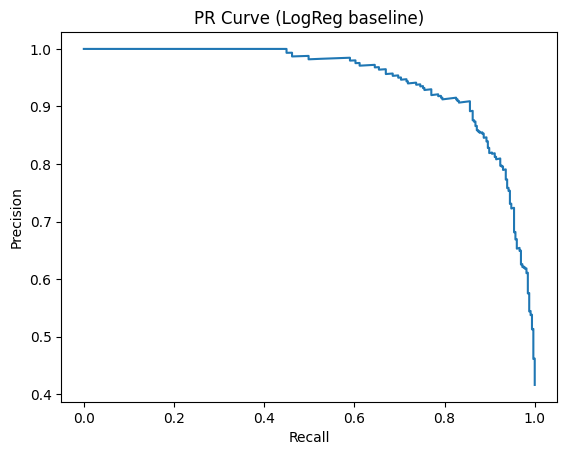

In [54]:
# PR curve for baseline 2

acc_lab6, f1_lab6, preds_lab6 = evaluate(
    baseline2, test_df["text"], test_df["label_num"], "baseline 2"
)
from sklearn.metrics import precision_recall_curve

scores = baseline2.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (LogReg baseline)")
plt.show()

In [55]:
# TF-IDF word(1,2) + Linear SVC

from sklearn.svm import LinearSVC

svm_word = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        max_features=7000
    )),
    ("clf", LinearSVC())
])

svm_word.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2))),
                ('clf', LinearSVC())])

SVM word Accuracy: 0.8944020356234097
SVM word Macro-F1: 0.8902432253733679


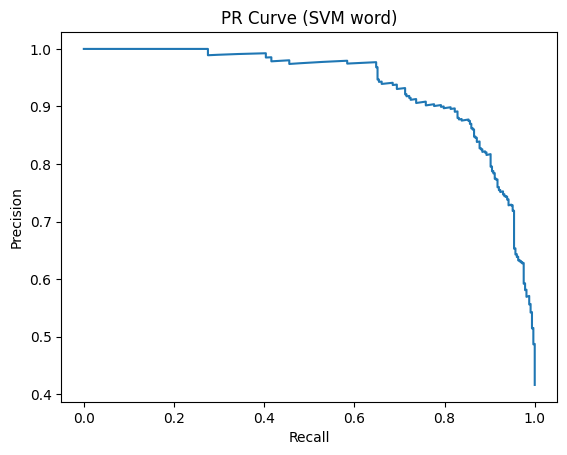

In [56]:
# PR curve

acc_svm_w, f1_svm_w, preds_svm_w = evaluate(
    svm_word, test_df["text"], test_df["label_num"], "SVM word"
)
from sklearn.metrics import precision_recall_curve

scores = svm_word.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (SVM word)")
plt.show()

In [57]:
# TF-IDF word(1,2) + Linear SVC balanced

svm_word_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        max_features=7000
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

svm_word_balanced.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2))),
                ('clf', LinearSVC(class_weight='balanced'))])

SVM balanced Accuracy: 0.8893129770992366
SVM balanced Macro-F1: 0.8856325731918416


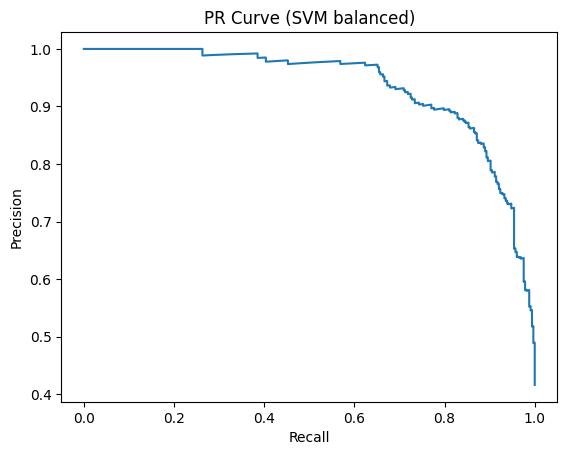

In [58]:
# PR curve

acc_svm_w_b, f1_svm_w_b, preds_svm_w_b = evaluate(
    svm_word_balanced, test_df["text"], test_df["label_num"], "SVM balanced"
)
from sklearn.metrics import precision_recall_curve

scores = svm_word_balanced.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (SVM balanced)")
plt.show()

In [59]:
# TF-IDF char(3,5) + Linear SVC

svm_char = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3,5),
        max_features=10000
    )),
    ("clf", LinearSVC())
])

svm_char.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_range=(3, 5))),
                ('clf', LinearSVC())])

SVM char Accuracy: 0.9300254452926209
SVM char Macro-F1: 0.9276300040010246


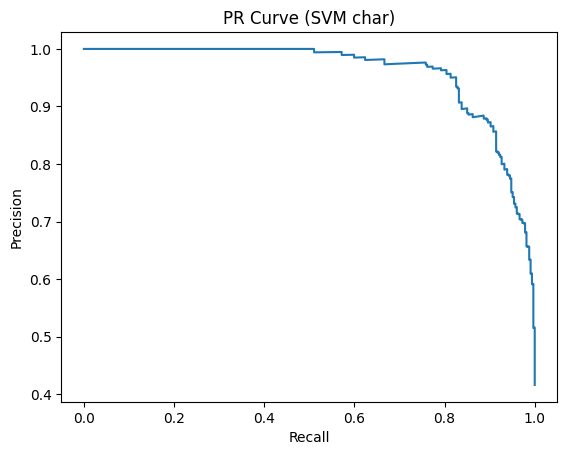

In [60]:
# PR curve

acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    svm_char, test_df["text"], test_df["label_num"], "SVM char"
)
from sklearn.metrics import precision_recall_curve

scores = svm_char.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (SVM char)")
plt.show()

In [61]:
# TF-IDF char(3,5) + Linear SVC balanced

svm_char_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3,5),
        max_features=10000
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

svm_char_balanced.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_range=(3, 5))),
                ('clf', LinearSVC(class_weight='balanced'))])

SVM char Accuracy: 0.9338422391857506
SVM char Macro-F1: 0.9320972886762361


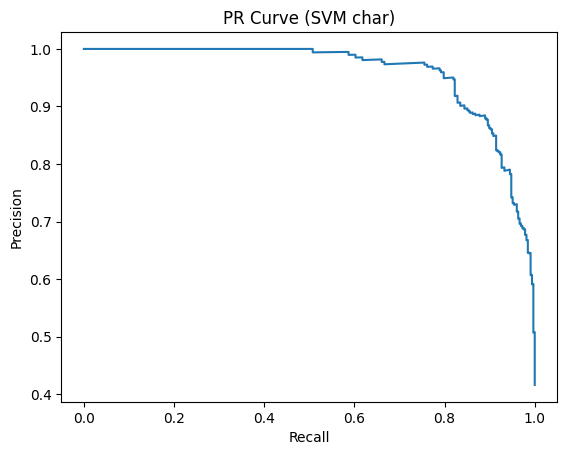

In [62]:
# PR curve

acc_svm_c_b, f1_svm_c_b, preds_svm_c_b = evaluate(
    svm_char_balanced, test_df["text"], test_df["label_num"], "SVM char"
)
from sklearn.metrics import precision_recall_curve

scores = svm_char_balanced.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (SVM char)")
plt.show()

In [63]:
# Models comparison

from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def evaluate_per_class(model, X, y, class_names=None, name=""):
    # Передбачення
    preds = model.predict(X)

    # Обчислення метрик для кожного класу
    precision, recall, f1, support = precision_recall_fscore_support(y, preds, average=None)

    # Якщо не передані назви класів, використовуємо індекси
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(precision))]

    # Формуємо таблицю результатів
    results_df = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Support": support
    })

    print(f"\n{name} per-class evaluation:")
    print(results_df)

    return results_df

In [64]:
# per class evaluation
results_train = evaluate_per_class(svm_char, train_df["text"], train_df["label_num"], name="Train svm_char")
results_val   = evaluate_per_class(svm_char, val_df["text"], val_df["label_num"], name="Val svm_char")
results_test  = evaluate_per_class(svm_char, test_df["text"], test_df["label_num"], name="Test svm_char")


Train svm_char per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.984354  0.994820  0.989559     3668
1  Class 1   0.992639  0.977863  0.985195     2620

Val svm_char per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.896624  0.925926   0.91104      459
1  Class 1   0.891026  0.850153   0.87011      327

Test svm_char per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.927813  0.954148  0.940797      458
1  Class 1   0.933333  0.896341  0.914463      328


In [65]:
# results

results = pd.DataFrame({
    "Model": [
        "SVM word",
        "SVM word balanced",
        "SVM char",
        "SVM char balanced"
    ],
    "Features": [
        "word(1,2)",
        "word(1,2)",
        "char(3,5)",
        "char(3,5)"
    ],
    "class_weight": [
        "no",
        "balanced",
        "no",
        "balanced"
    ],
    "Accuracy": [
        acc_svm_w,
        acc_svm_w_b,
        acc_svm_c,
        acc_svm_c_b
    ],
    "Macro-F1": [
        f1_svm_w,
        f1_svm_w_b,
        f1_svm_c,
        f1_svm_c_b
    ]
})

results

,Model,Features,class_weight,Accuracy,Macro-F1
0,SVM word,"word(1,2)",no,0.894402,0.890243
1,SVM word balanced,"word(1,2)",balanced,0.889313,0.885633
2,SVM char,"char(3,5)",no,0.930025,0.927630
3,SVM char balanced,"char(3,5)",balanced,0.933842,0.932097


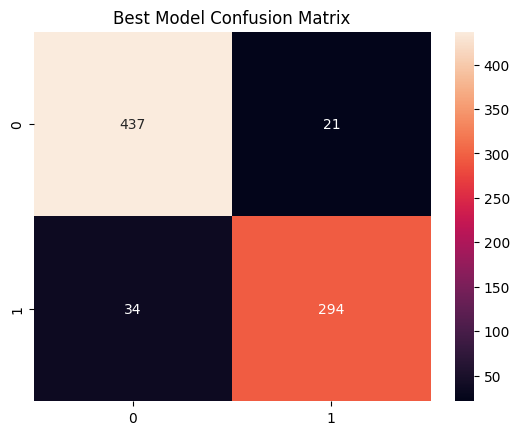

In [66]:
# confusion matrix

best_preds = preds_svm_c

cm = confusion_matrix(test_df["label_num"], best_preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Best Model Confusion Matrix")
plt.show()

In [67]:
# errors

errors = test_df.copy()
errors["pred"] = best_preds

errors = errors[errors["label_num"] != errors["pred"]]

errors_sample = errors.sample(10, random_state=42)

errors_sample[["text_id", "text", "label", "pred"]]

,text_id,text,label,pred
1596,1596,україну висміяли на вуличному графіті в ізраїл...,Fake,0
4753,4753,відомо вже про 2 загиблих та 15 поранених в дн...,Real,1
2584,2584,"скрипальна справа - це трюк ""мертвої кішки"", я...",Fake,0
1630,1630,обкладинка charlie hebdo з емманюелем макроном...,Fake,0
2905,2905,сорос намагається сіяти розбрат між європою та...,Fake,0
277,277,роcіяни vбили маму вiдомої укpаїнської споpтсм...,Fake,0
3253,3253,"до зустрічі g7 в японії 10 квітня, німецька .....",Fake,0
2320,2320,швеція каже муніципалітетам підготуватися до в...,Fake,0
2977,2977,"німеччина попереджає, що він подасть до суду н...",Fake,0
551,551,атака росії по одесі! кiлькість <email> та поp...,Fake,0


In [68]:
import json

with open("error_cases_models.jsonl", "w", encoding="utf-8") as f:
    for _, row in errors_sample.iterrows():
        f.write(json.dumps({
            "text_id": int(row["text_id"]),
            "text": row["text"][:300],
            "true": row["label"],
            "pred": int(row["pred"]),
            "comment": ""
        }, ensure_ascii=False) + "\n")

## Other models

In [69]:
# 1. TF-IDF word(1,2) + MultinomialNB

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

nb_word = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20000)),
    ("clf", MultinomialNB())
])

nb_word.fit(train_df["text"], train_df["label_num"])

acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    nb_word, test_df["text"], test_df["label_num"], "SVM char"
)

SVM char Accuracy: 0.8625954198473282
SVM char Macro-F1: 0.8546289002294756


In [70]:
# 2. TF-IDF word(1,2) + RidgeClassifier

from sklearn.linear_model import RidgeClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

ridge_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20000)),
    ("clf", RidgeClassifier())
])

ridge_tfidf.fit(train_df["text"], train_df["label_num"])

acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    ridge_tfidf, test_df["text"], test_df["label_num"], "SVM char"
)

SVM char Accuracy: 0.8918575063613231
SVM char Macro-F1: 0.8872433609275714


In [71]:
# 3. TF-IDF char(3,5) + PassiveAggressiveClassifier

from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

pa_char = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), max_features=10000)),
    ("clf", PassiveAggressiveClassifier(class_weight="balanced", max_iter=1000))
])

pa_char.fit(train_df["text"], train_df["label_num"])

acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    pa_char, test_df["text"], test_df["label_num"], "SVM char"
)

SVM char Accuracy: 0.8905852417302799
SVM char Macro-F1: 0.888234126984127


In [72]:
# 5. TF-IDF char(3,5) + RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

rf_char = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), max_features=8000)),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1))
])

rf_char.fit(train_df["text"], train_df["label_num"])

acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    rf_char, test_df["text"], test_df["label_num"], "SVM char"
)

SVM char Accuracy: 0.9236641221374046
SVM char Macro-F1: 0.9197303921568627


In [73]:
# 6. TF-IDF word(1,2) + XGBClassifier

!pip install xgboost
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

xgb_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=15000)),
    ("clf", XGBClassifier(use_label_encoder=False, eval_metric="logloss", n_jobs=-1))
])

xgb_tfidf.fit(train_df["text"], train_df["label_num"])

acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    xgb_tfidf, test_df["text"], test_df["label_num"], "SVM char"
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:19:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM char Accuracy: 0.8867684478371501
SVM char Macro-F1: 0.8827791564938645


In [74]:
# 7. TF-IDF word(1,2) + MLPClassifier

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

mlp_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20000)),
    ("clf", MLPClassifier(hidden_layer_sizes=(512,256), max_iter=30, early_stopping=True))
])

mlp_tfidf.fit(train_df["text"], train_df["label_num"])

acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    mlp_tfidf, test_df["text"], test_df["label_num"], "SVM char"
)

SVM char Accuracy: 0.8905852417302799
SVM char Macro-F1: 0.8871051787718454


### Other models comparison

Running CV for 1_NB_word ...
Running CV for 2_Ridge_word ...
Running CV for 3_PA_char ...
Running CV for 5_RF_char ...
Running CV for 6_XGB_word ...
Running CV for 7_MLP_word ...
          model  f1_macro_mean  f1_macro_std  accuracy_mean  accuracy_std
3     5_RF_char       0.901750      0.008439       0.906808      0.007705
2     3_PA_char       0.897525      0.007860       0.900607      0.007576
1  2_Ridge_word       0.895254      0.005751       0.899492      0.005552
4    6_XGB_word       0.894598      0.009410       0.898536      0.009032
5    7_MLP_word       0.883597      0.013684       0.887404      0.012850
0     1_NB_word       0.866346      0.011164       0.872934      0.010700


/tmp/ipykernel_13655/57480239.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["model"], rotation=45, ha="right")
/tmp/ipykernel_13655/57480239.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["model"], rotation=45, ha="right")
/tmp/ipykernel_13655/57480239.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["model"], rotation=45, ha="right")
/tmp/ipykernel_13655/57480239.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["model"], rotation=45, ha="right")


<Figure size 1200x600 with 0 Axes>

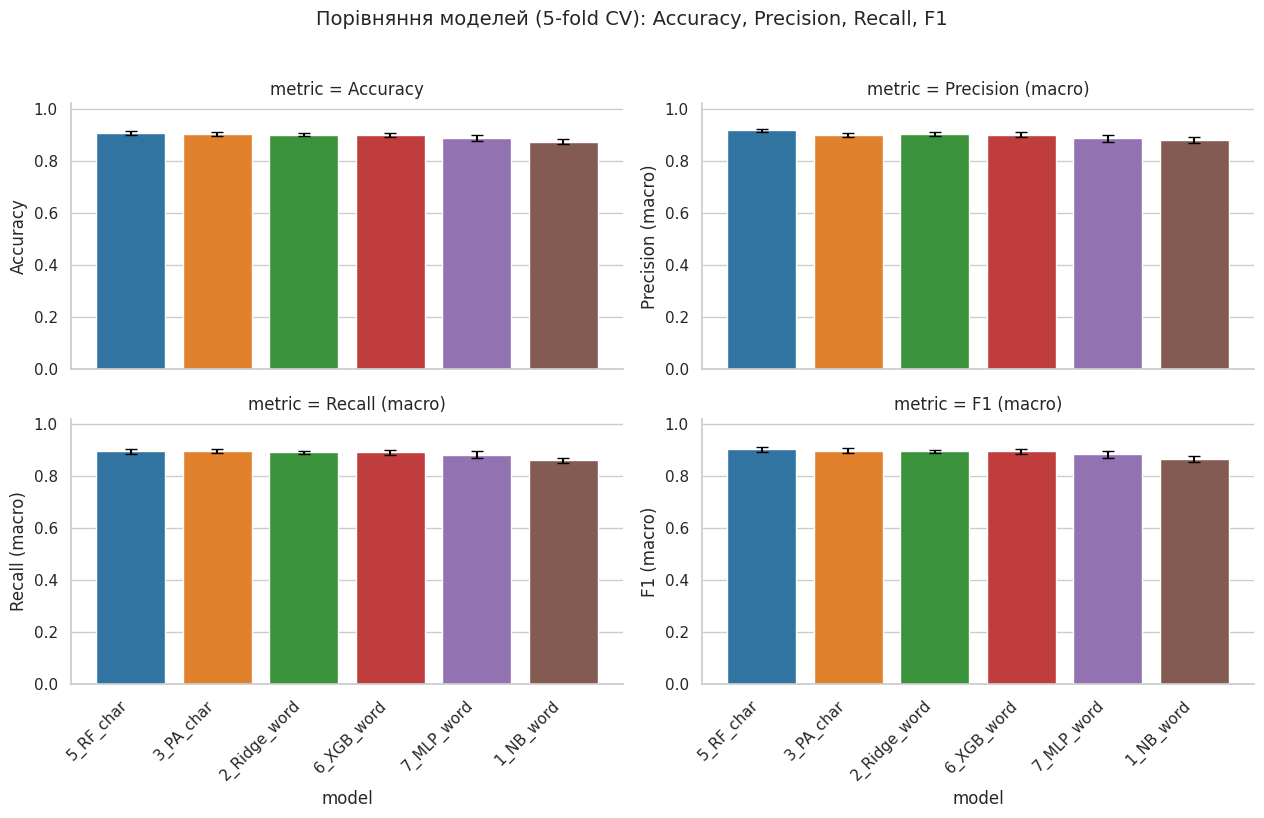


Результати (середнє ± std) у відсотках:
       model  accuracy_mean_pct  precision_macro_mean_pct  recall_macro_mean_pct  f1_macro_mean_pct  accuracy_std_pct  precision_macro_std_pct  recall_macro_std_pct  f1_macro_std_pct
   5_RF_char              90.68                     91.71                  89.39              90.17              0.77                     0.62                  0.91              0.84
   3_PA_char              90.06                     89.88                  89.67              89.75              0.76                     0.80                  0.81              0.79
2_Ridge_word              89.95                     90.24                  89.08              89.53              0.56                     0.67                  0.58              0.58
  6_XGB_word              89.85                     89.96                  89.11              89.46              0.90                     0.96                  0.94              0.94
  7_MLP_word              88.74             

In [75]:
# Порівняння моделей: крос-валідація і підсумковий графік
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import RidgeClassifier, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Моделі: XGBoost якщо є, інакше HistGradientBoostingClassifier як запасний варіант
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    xgb_available = False

# Визначення пайплайнів
models = {
    "1_NB_word": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20000)),
        ("clf", MultinomialNB())
    ]),
    "2_Ridge_word": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20000)),
        ("clf", RidgeClassifier())
    ]),
    "3_PA_char": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), max_features=10000)),
        ("clf", PassiveAggressiveClassifier(class_weight="balanced", max_iter=1000))
    ]),
    "5_RF_char": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), max_features=8000)),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=42))
    ]),
}

# Модель 6: XGB або HGB)
if xgb_available:
    models["6_XGB_word"] = Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=15000)),
        ("clf", XGBClassifier(use_label_encoder=False, eval_metric="logloss", n_jobs=-1, random_state=42))
    ])
else:
    models["6_HGB_word"] = Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=15000)),
        ("clf", HistGradientBoostingClassifier(random_state=42))
    ])

# Модель 7: MLP
models["7_MLP_word"] = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20000)),
    ("clf", MLPClassifier(hidden_layer_sizes=(512,256), max_iter=50, early_stopping=True, random_state=42))
])

# Параметри крос-валідації і метрики
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

# Підготовка даних: використовуємо train_df з колонками 'text' і 'label_num'
X = train_df["text"].astype(str).values
y = train_df["label_num"].values

results = []
for name, pipe in models.items():
    print(f"Running CV for {name} ...")
    # cross_validate повертає масиви для кожної метрики
    cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    # обчислення середнього і std для кожної метрики
    row = {"model": name}
    for metric in scoring:
        vals = cv_res[f"test_{metric}"]
        row[f"{metric}_mean"] = np.mean(vals)
        row[f"{metric}_std"] = np.std(vals)
    results.append(row)

df_res = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)
print(df_res[["model","f1_macro_mean","f1_macro_std","accuracy_mean","accuracy_std"]])

# Побудова графіків: групований barplot для метрик з error bars
metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
metric_labels = {"accuracy":"Accuracy", "precision_macro":"Precision (macro)", "recall_macro":"Recall (macro)", "f1_macro":"F1 (macro)"}

# Підготовка даних для seaborn
plot_rows = []
for _, r in df_res.iterrows():
    for m in metrics:
        plot_rows.append({
            "model": r["model"],
            "metric": metric_labels[m],
            "mean": r[f"{m}_mean"],
            "std": r[f"{m}_std"]
        })
plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(12,6))
sns.set(style="whitegrid")
# Створення facet: кожна метрика — свій subplot
g = sns.catplot(
    data=plot_df,
    x="model", y="mean", hue="model",
    col="metric", kind="bar",
    col_wrap=2, sharey=False,
    height=4, aspect=1.6, palette="tab10",
    legend=False
)

# Додавання error bars
for ax, metric in zip(g.axes.flatten(), plot_df["metric"].unique()):
    sub = plot_df[plot_df["metric"] == metric]
    x_coords = np.arange(len(sub))
    ax.errorbar(x_coords, sub["mean"], yerr=sub["std"], fmt='none', ecolor='black', capsize=4)
    ax.set_xticklabels(sub["model"], rotation=45, ha="right")
    ax.set_ylim(0, 1.02)
    ax.set_ylabel(metric)

plt.suptitle("Порівняння моделей (5‑fold CV): Accuracy, Precision, Recall, F1", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Таблиця з результатами у відсотках
display_df = df_res.copy()
for m in metrics:
    display_df[f"{m}_mean_pct"] = (display_df[f"{m}_mean"] * 100).round(2)
    display_df[f"{m}_std_pct"] = (display_df[f"{m}_std"] * 100).round(2)
cols = ["model"] + [f"{m}_mean_pct" for m in metrics] + [f"{m}_std_pct" for m in metrics]
print("\nРезультати (середнє ± std) у відсотках:")
print(display_df[cols].to_string(index=False))
